# KIWI-GA

In [2]:
import sys
import os
import paths_NN as ppp
import pickle
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as sps
from scipy.optimize import minimize
import schwimmbad
import PyAstronomy
import PyPDF2
import tensorflow as tf
import keras
from keras.models import load_model
import json
import pandas as pd
from astropy.io import fits
import warnings
from IPython.display import display, clear_output
import timeit
from scipy.signal import convolve
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.special import erf
from scipy.signal import fftconvolve
import comparing_everything as ce

sys.path.insert(0, os.path.join(os.path.dirname('ga_notebook_tools.py'), 'KIWI-GA'))
import ga_notebook_tools as ga


In [3]:
#import the wavelength array for the predictions
#all have the same wavelengths
df = pd.read_csv(ppp.master_wl_array_path)
master_wl_array = np.asarray(df['master wl Halpha_HeII6527 combined model 19002'])
order = np.argsort(master_wl_array)              # indices to sort wavelength array
master_wl_ordered = master_wl_array[order]
master_wl_unique, unique_idx = np.unique(master_wl_ordered, return_index=True)  # deduplicated grid
wl_min, wl_max = master_wl_unique.min(), master_wl_unique.max()
UNIFORM_STEP = 0.2                               # BLOeM resolution scale (~0.2 Å)
wl_uniform = np.arange(wl_min, wl_max, UNIFORM_STEP)
cc = 2.99792458e10 #speed of light in a vacuum;
C_KMS = cc * 1e-5

# --- Ks filter transmission ---
band = 'SPHERE_Ks'
filterfile = 'SPHERE_IRDIS_B_Ks.dat'
filterdir = ppp.filter_path
_KS_WAVE, _KS_TRANS = np.genfromtxt(filterdir + filterfile, comments='#').T
_KS_WAVE *= 10  # nm → Å
zpfile = filterdir + 'zero_points.dat'
zp_values = np.genfromtxt(zpfile, comments='#', dtype=str)
zp_system = 'vega'  # Choose zero point system: 'vega', 'AB', or 'ST'
zpflux = ''
for afilter in zp_values:
    if afilter[0] == band:
        if zp_system == 'vega':
            zpflux = float(afilter[1])
        elif zp_system == 'AB':
            zpflux = float(afilter[2])
        elif zp_system == 'ST':
            zpflux = float(afilter[3])

# --- Parameter names (order must match theta vector throughout) ---
PARAM_NAMES = ['teff', 'logg', 'radius', 'logmdot', 'yhe', 'vsini']
PARAM_NAMES_AS_KIWIGA = ['teff', 'logg', 'radius', 'mdot', 'yhe', 'vrot']
PARAM_BOUNDS = np.array([
    [29000, 52000],  # teff
    [3.4,   4.3  ],  # logg
    [6,     21   ],  # radius
    [-7.5,  -5.2 ],  # logmdot
    [0.08,  0.15 ],  # yhe
    [50.0,  399.0],  # vsini
])

#import Anja's model for inference
model = keras.saving.load_model(ppp.keras_model_path)

# Load the normalization values
with open(ppp.norm_path) as f:
    normalization = json.load(f)

In [4]:
def planck_wavelength(wave_angstrom, temp):
    ''' Calculate the Planck function as function of temperature and wavelength (in Angstrom. Output is then also in Angstrom).'''
    angstrom_to_cm = 1e-8
    wave = wave_angstrom * angstrom_to_cm
    # All units in cgs
    hh = 6.6260755e-27 #Planck constant;
    kk = 1.380658e-16 #Boltzmann constant;

    prefactor = 2.0 * hh * cc**2 / (wave**5)
    exponent = (hh * cc / kk) / (wave * temp)
    Blambda = prefactor * (1.0 / (np.exp(exponent)-1))
    Blambda = Blambda * angstrom_to_cm #Blambda from per cm to per angstrom
    return Blambda

def flux_to_magnitude(obsflux):
    ''' Calculate magnitude from observed flux and zeropoint flux'''
    magnitude = -2.5 * np.log10(obsflux / zpflux)
    return magnitude

def compute_obs_flux(teff, radius, Tfrac=0.9, d=50e3*3.08567758e18/6.96e10):
    ''' Calculate the observed flux in the K-band based on the given parameters.
    teff: effective temperature (K)
    radius: stellar radius (solar radii)
    Tfrac: fraction of teff to use for the blackbody calculation (default 0.9 to account for line formation in cooler layers)
    d: distance to the star (default 50 kpc in cm (distance to LMC), converted to solar radii)
    '''
    tBB = teff * Tfrac
    F_lambda = np.pi * planck_wavelength(_KS_WAVE, tBB)
    filtered_flux = np.trapz(_KS_TRANS * F_lambda, _KS_WAVE) / np.trapz(_KS_TRANS, _KS_WAVE)
    return (radius / d)**2 * filtered_flux

def normalize(col_name, unnormalized_val):
    mn = normalization[f'{col_name}_min']
    mx = normalization[f'{col_name}_max']
    return (unnormalized_val - mn) / (mx - mn)

def normalize_theta(theta):
    return np.array([normalize(name, val) for name, val in zip(PARAM_NAMES, theta)])

def add_noise_to_spectrum(prediction, spectral_snr):
    '''add Gaussian noise to the prediction and plot again'''
    spectral_sigma = 1/spectral_snr
    noisy_flux = prediction + np.random.normal(0.0, spectral_sigma, size=prediction.shape)
    return noisy_flux

def _gray_kernel(v_grid, vsini, epsilon):
    """
    Evaluate the Gray rotational broadening profile on a uniform velocity grid
    and return a kernel normalised to **unit sum** (dimensionless).

    Parameters
    ----------
    v_grid : 1-D array  [km s⁻¹]
        Uniformly spaced velocity values, centred at 0.  The array length
        *must* be odd so that the kernel centre falls exactly on a grid point.
    vsini : float  [km s⁻¹]
        Projected equatorial rotation speed.
    epsilon : float
        Linear limb-darkening coefficient (0 <= e <= 1).

    Returns
    -------
    kernel : 1-D array
        Broadening profile normalised so that ``kernel.sum() == 1``.
        Convolve directly with a flux array; no extra ``* dv`` factor needed.
    """
    assert len(v_grid) % 2 == 1, "v_grid must have odd length (centred kernel)."

    x  = v_grid / vsini
    c1 = 2.0 * (1.0 - epsilon) / (np.pi * vsini * (1.0 - epsilon / 3.0))
    c2 = epsilon / (2.0 * vsini * (1.0 - epsilon / 3.0))

    kernel = np.zeros_like(v_grid, dtype=np.float64)
    inside = np.abs(x) < 1.0
    kernel[inside] = (c1 * np.sqrt(1.0 - x[inside] ** 2) + c2 * (1.0 - x[inside] ** 2))

    # Convert continuous density [per km/s] to discrete weights by
    # multiplying by the bin width, then renormalise for numerical safety.
    # After this step kernel.sum() == 1 exactly (up to floating-point noise).
    dv    = v_grid[1] - v_grid[0]
    kernel *= dv          # approximates integral of G(v) over each bin
    total  = kernel.sum()
    if total == 0.0:
        raise ValueError(
            f"Gray kernel is all zeros for vsini={vsini} km/s and "
            f"dv={dv:.4f} km/s.  Increase n_vel or oversample."
        )
    kernel /= total       # unit sum — convolve without extra factors
    return kernel

def vspace_broadening(wvl, flux, vsini, epsilon=0.6, n_vel=None, oversample=1):
    """
    Apply rotational broadening via a single convolution in velocity space.
    ----------
    wvl : array  [A]
        Wavelength array.  Does **not** need to be uniformly spaced.
    flux : array
        Flux array, same length as `wvl`.
    vsini : float  [km/s]
        Projected rotational velocity.
    epsilon : float
        Linear limb-darkening coefficient (0 to 1).  Default 0.6.
    n_vel : int, optional
        Number of points for the internal uniform log-lambda grid.  Defaults to
        ``len(wvl) * oversample``.  Must be large enough that the velocity
        pixel size ``dv = (ln lam_max - ln lam_min) / (n_vel-1) * c`` is
        smaller than ``vsini`` (otherwise the kernel degenerates to a delta).
    oversample : int
        Oversampling factor relative to ``len(wvl)`` when `n_vel` is not
        given.  Values > 1 improve accuracy when the input grid is coarse.
    -------
    flux_broad : array
        Broadened flux, same length as `flux`.
    """
    wvl  = np.asarray(wvl,  dtype=np.float64)
    flux = np.asarray(flux, dtype=np.float64)

    if vsini <= 0.0:
        raise ValueError("vsini must be positive.")
    if not (0.0 <= epsilon <= 1.0):
        raise ValueError("epsilon must be between 0 and 1.")
    if len(wvl) != len(flux):
        raise ValueError("wvl and flux must have the same length.")

    # Build a uniform grid in ln(lambda)  <->  velocity space
    ln_wvl = np.log(wvl)

    if n_vel is None:
        n_vel = len(wvl) * oversample

    ln_wvl_uniform = np.linspace(ln_wvl[0], ln_wvl[-1], n_vel)
    dv = (ln_wvl_uniform[1] - ln_wvl_uniform[0]) * C_KMS  # km/s per pixel

    # Interpolate flux onto the uniform ln-lambda grid
    interp_in    = interp1d(ln_wvl, flux, kind="linear", bounds_error=False, fill_value=(flux[0], flux[-1]))
    flux_uniform = interp_in(ln_wvl_uniform)

    # Build the kernel on a centred, odd-length velocity grid
    half_width = int(np.ceil(vsini / dv)) + 1   # at least vsini/dv bins
    v_kernel   = np.arange(-half_width, half_width + 1) * dv  # odd length
    kernel     = _gray_kernel(v_kernel, vsini, epsilon)        # unit-sum

    # Convolve  (single FFT-based convolution - O(N log N))
    # kernel.sum() == 1, so no extra scaling factor needed.
    flux_broad_uniform = fftconvolve(flux_uniform, kernel, mode="same")
    # Reflection-pad to suppress edge ringing before convolving
    pad = len(kernel)
    flux_padded = np.pad(flux_uniform, pad, mode="reflect")
    conv_padded = fftconvolve(flux_padded, kernel, mode="same")
    flux_broad_uniform = conv_padded[pad:-pad]

    # Interpolate back onto the original wavelength grid
    interp_out = interp1d(ln_wvl_uniform, flux_broad_uniform, kind="linear", bounds_error=False, fill_value=(flux_broad_uniform[0], flux_broad_uniform[-1]))
    return interp_out(ln_wvl)

def simulate_model_spectrum(theta, output_wl=None):
    ''' Simulate the model spectrum for given parameters, with optional rotational broadening and interpolation to an output wavelength grid.
    theta: array of parameters [teff, logg, radius, logmdot, yhe]
    model: keras model to predict the spectrum
    vsini: projected rotational velocity (km/s) for rotational broadening (optional)
    output_wl: wavelength grid to interpolate the final spectrum onto (optional; if None, returns on wl_uniform grid)
    '''
    theta_in_model=theta[:5] # extract teff, logg, radius, logmdot, yhe
    norm_params = normalize_theta(theta_in_model) # normalize the input parameters to the [0,1] range expected by the model
    vsini=theta[5] # extract vsini
    flux_master = model(norm_params[None, :], training=False).numpy().ravel() 
    flux_master_ordered = flux_master[order] # reorder + deduplicate
    flux_unique = flux_master_ordered[unique_idx] # flux_master is now on the master_wl_unique grid
    flux_out = np.interp(wl_uniform,master_wl_unique,flux_unique) # interpolate master → uniform grid
    if vsini == 0:
        flux_out = np.interp(output_wl,wl_uniform,flux_out) if output_wl is not None else flux_out # if no broadening, just interpolate to output grid if needed
    if vsini > 0:
        flux_out = vspace_broadening(wvl=wl_uniform, flux=flux_out, vsini=vsini)
    if output_wl is not None:
        flux_out=np.interp(output_wl,wl_uniform,flux_out) # interpolate master → output grid
    return flux_out

def simulate_kband_magnitude(theta):
    ''' Simulate the K-band magnitude for given parameters using a simple model based on the Planck function and filter transmission.'''
    teff, logg, radius, logmdot, yhe, vsini = theta
    # Calculate the K-band magnitude based on the parameters using a simple model
    model_flux = compute_obs_flux(teff, radius) # Calculate the observed flux in the K-band based on the given parameters
    kband_mag = flux_to_magnitude(model_flux) # Convert the observed flux to a K-band magnitude
    return kband_mag


In [ ]:
#remember to change the radius in radius_info.txt when simulating and parameter_space.txt when including extra params!!!!
theta_true=[40000, 4, 8, -7, 0.1, 200]
spectral_snr=100
kband_snr=20
kband_magnitude_with_noise = simulate_kband_magnitude(theta_true) + np.random.normal(0, 1/kband_snr) # Simulate the observed K-band magnitude for the true parameters and add noise based on a K-band SNR of 20
observed_flux = simulate_model_spectrum(theta_true, output_wl=wl_uniform) # Simulate a model spectrum
noisy_flux = add_noise_to_spectrum(observed_flux, spectral_snr=spectral_snr) # Add noise to the simulated spectrum based on the specified SNR
error = np.random.normal(0.0, 1/spectral_snr, size=noisy_flux.shape) # errors needed for the spectrum.norm file

In [ ]:
plt.figure(figsize=(15, 6), dpi=1200)
plt.plot(wl_uniform, noisy_flux, label=f"'observed' spectrum", lw=0.8)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

#now put this spectrum in the file spectrum.norm, which has the columns: Wavelength in Angstroms, Normalised flux, Error bars on the measurements
#filepath_to_run_inputs = os.path.join(ppp.inpath, 'automated2')
#with open(filepath_to_run_inputs + "/spectrum.norm", "w") as f:
#    for wl, fl, err in zip(wl_uniform, noisy_flux, error):
#        f.write(f"{wl} {fl} {err}\n")

In [ ]:
run = 'automated2'
ga.check_paths(run)

# Write inputs for a single run
ga.write_spectrum_norm(run, wl_uniform, noisy_flux, spectral_snr=100)
ga.write_radius_info(run, "2MASS_Ks", kband_magnitude_with_noise)
ga.write_parameter_space(
    run,
    free_params={
        "teff":  (29000, 52000, 100),
        "logg":  (3.4,   4.3,   0.05),
        "mdot":  (-7.5,  -5.2,  0.1),
        "yhe":   (0.08,  0.15,  0.01),
        "vrot":  (50,    399,   5),
        "vinf":  (-1,    -1,    0),
        "macro": (-1,    -1,    0),
    }
)
ga.copy_template_inputs(run, ppp.example_input_path, files = ["control.txt", "defaults_fastwind.txt", "line_list.txt"])

# Launch the GA
ga.run_ga(run, n_cores=4)   # blocks until done
ga.check_paths(run)

In [ ]:
# --- Read results ---
result = ga.get_ga_best_and_intervals(run, param_names=PARAM_NAMES_AS_KIWIGA)
print(result["best"])        # {'teff': 40200, 'logg': 4.01, ...}
print(result["lower_1sig"])  # lower bounds
print(result["upper_1sig"])  # upper bounds

# Check how many models are in the 1sigma set
df = result["df"]
chi2_vals = df["chi2"].values
scaling = chi2_vals.min()
dof_tot = int(df["dof"].iloc[df["rchi2"].idxmin()])
chi2_norm = chi2_vals * dof_tot / scaling
import scipy.stats as stats
pvals = [stats.chi2.sf(c, dof_tot) for c in chi2_norm]
n_1sig = sum(p >= 0.317 for p in pvals)
n_total = len(df)
print(f"Models in 1sigma set: {n_1sig} / {n_total}")

radius_info  = ga.get_radius_intervals_from_kband(result, kband_magnitude_with_noise)
print(f"radius best:   {radius_info['best']:.2f}")
print(f"radius 1sigma: {radius_info['lower_1sig']:.2f} – {radius_info['upper_1sig']:.2f}")
print(f"radius 2sigma: {radius_info['lower_2sig']:.2f} – {radius_info['upper_2sig']:.2f}")

In [ ]:
# Override the private simulation function with your actual code
def _simulate_data_for_coverage(theta_true):
    observed_flux = simulate_model_spectrum(theta_true, output_wl=wl_uniform)
    observed_flux = add_noise_to_spectrum(observed_flux, spectral_snr)
    observed_kband = simulate_kband_magnitude(theta_true) + np.random.normal(0, 1/kband_snr)
    return observed_flux, wl_uniform, observed_kband

# Patch it into the module so run_ga_coverage_test picks it up
ga._simulate_data_for_coverage = _simulate_data_for_coverage

# Write inputs function — note that parameter_space.txt is NOT copied from template
# because it's the same for every simulation (same prior ranges, same step sizes)
def my_write_inputs(run_name, theta_true, flux, wl, kband):
    ga.write_spectrum_norm(run_name, wl, flux, spectral_snr=spectral_snr)
    ga.write_radius_info(run_name, "2MASS_Ks", kband)
    ga.copy_template_inputs(run_name, "automated",
        files=["control.txt", "defaults_fastwind.txt", "line_list.txt"])
    ga.write_parameter_space(run_name, free_params={
        "teff":  (29000, 52000, 50),
        "logg":  (3.4,   4.3,   0.01),
        "mdot":  (-7.5,  -5.2,  0.01),
        "yhe":   (0.08,  0.15,  0.001),
        "vrot":  (50,    399,   1),
        "vinf":  (-1,    -1,    0),
        "macro": (-1,    -1,    0),
    })

# Run the coverage test
coverage, theta_true_all, results, kband_all = ga.run_ga_coverage_test(
    run_name_prefix="coverage_test",
    write_inputs_fn=my_write_inputs,
    N_sims=20,
    n_cores=4,
    dof_tot=2188,   # from your chi2.txt
)

save_dir = "/Users/hulya/Desktop/Alles/UvA/MSc_project/Anja_NN/Statistical-Inference-for-Massive-Stars-MSc-Project/KIWI-GA/output/automated/coverage_test_results/"
os.makedirs(save_dir, exist_ok=True)

np.save(save_dir + "theta_true_all.npy", theta_true_all)
np.save(save_dir + "kband_all.npy", kband_all)
with open(save_dir + "coverage.pkl", "wb") as f:
    pickle.dump(coverage, f)
with open(save_dir + "results.pkl", "wb") as f:
    pickle.dump(results, f)
print("Saved!")


Radius coverage: 15.0%


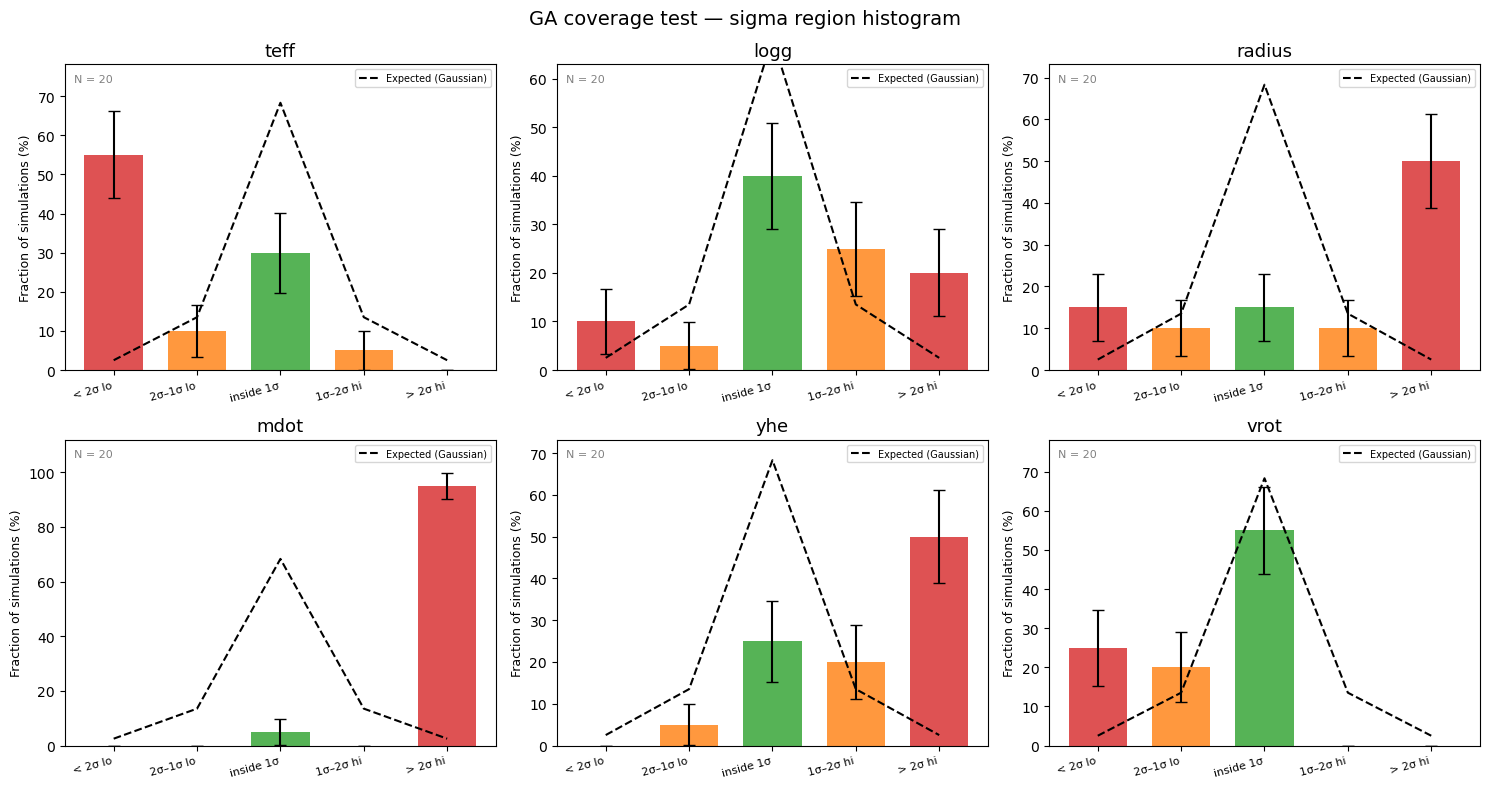

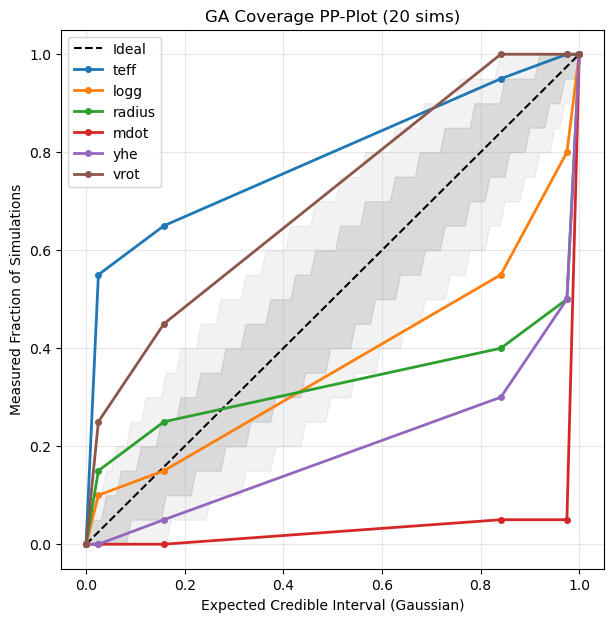

In [5]:
save_dir = "/Users/hulya/Desktop/Alles/UvA/MSc_project/Anja_NN/Statistical-Inference-for-Massive-Stars-MSc-Project/KIWI-GA/output/automated/coverage_test_results/"
theta_true_all = np.load(save_dir + "theta_true_all.npy")
kband_all = np.load(save_dir + "kband_all.npy")

# Load .pkl files
with open(save_dir + "coverage.pkl", "rb") as f:
    coverage = pickle.load(f)

with open(save_dir + "results.pkl", "rb") as f:
    results = pickle.load(f)

radius_hits = []
for k, result in enumerate(results):
    if result is None:
        continue
    radius_info = ga.get_radius_intervals_from_kband(result, kband_all[k])
    true_radius = theta_true_all[k, 2]
    hit = radius_info["lower_1sig"] <= true_radius <= radius_info["upper_1sig"]
    radius_hits.append(hit)

print(f"Radius coverage: {np.mean(radius_hits)*100:.1f}%")

ga.plot_sigma_regions(coverage, param_names=PARAM_NAMES_AS_KIWIGA, results=results, kband_all=kband_all, theta_true_all=theta_true_all, radius_param_index=2 # index of radius in theta_true_all,
                         )

ga.plot_ga_coverage_pp(coverage, param_names=PARAM_NAMES_AS_KIWIGA, results=results, kband_all=kband_all, theta_true_all=theta_true_all, radius_param_index=2)


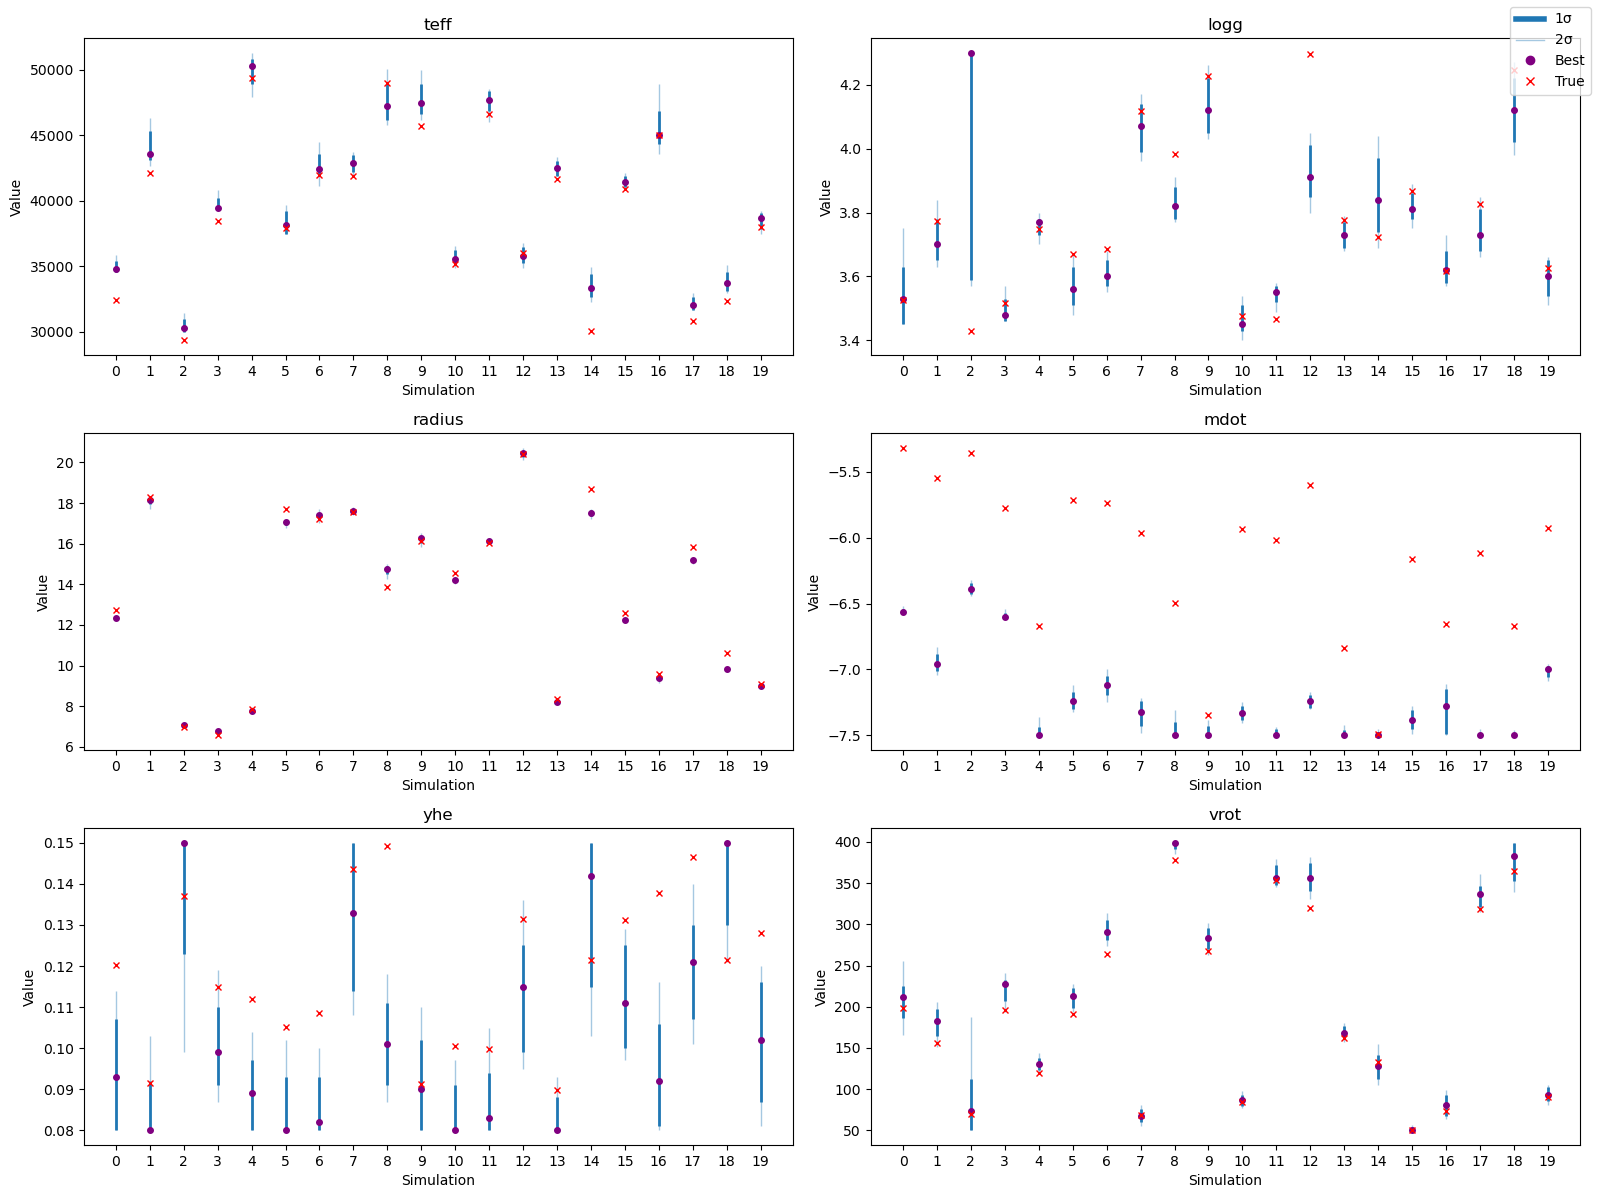

In [6]:
ga.plot_ga_best_vs_true(results, theta_true_all, kband_all=kband_all, param_names=PARAM_NAMES_AS_KIWIGA)

In [ ]:
# After run_ga_coverage_test, recompute radius coverage manually
radius_hits = []
for k, r in enumerate(results):
    if r is None:
        continue
    radius_info = ga.get_radius_intervals_from_kband(r, kband_all[k])
    true_radius = theta_true_all[k, 2]  # index 2 = radius
    hit = radius_info["lower_1sig"] <= true_radius <= radius_info["upper_1sig"]
    radius_hits.append(hit)
    print(f"sim {k:02d}: true={true_radius:.2f}, "
          f"interval=[{radius_info['lower_1sig']:.2f}, {radius_info['upper_1sig']:.2f}], "
          f"hit={hit}")

print(f"\nRadius coverage: {np.mean(radius_hits)*100:.1f}%")

# MCMC

# Running KIWI_GA
first: conda activate nn_env

second: mpirun -n 4 python kiwiga_Hhe_split.py test_run_with_NN_rotbroad

## Input files
[x] spectrum.norm: contains the observed spectrum. Created one with params (40000, 4, 8, -7, 0.1, 200, spectral_snr = 100, kband_snr=20)\
[x] parameter space.txt: specifies the free parameters and their ranges. (only use Teff, logg, logmdot, yhe, vrot, rest is -1)\
[x] line list.txt: specifies the spectral regions that needed to be fitted. (commented out all non H and HE lines)\
[x] radius_info.txt: specifies how the radius should be set. \
[x] control.txt: specifies control parameters of the algorithm. \
[x] defaults fastwind.txt: contains the default values of fastwind 


In [ ]:
df = pd.read_csv(
    "/Users/hulya/Desktop/Alles/UvA/MSc_project/Anja_NN/Statistical-Inference-for-Massive-Stars-MSc-Project/KIWI-GA/output/test_run_with_NN_rotbroad/chi2.txt",
    sep='\s+',   # split on spaces
    comment="#", # ignore the leading "#"
    header=None
)

# Now read header separately
with open("/Users/hulya/Desktop/Alles/UvA/MSc_project/Anja_NN/Statistical-Inference-for-Massive-Stars-MSc-Project/KIWI-GA/output/test_run_with_NN_rotbroad/chi2.txt") as f:
    header = f.readline().strip("# \n").split()

df.columns = header

# Find the row with the lowest rchi2 and get its runID and parameters
min_rchi2_row = df.loc[df['rchi2'].idxmin()]
min_rchi2 = min_rchi2_row['rchi2']
run_id_with_min_rchi2 = min_rchi2_row['run_id']
teff = min_rchi2_row['teff']
logg = min_rchi2_row['logg']
logmdot = min_rchi2_row['mdot']
yhe = min_rchi2_row['yhe']
radius = min_rchi2_row['radius']
vsini = min_rchi2_row['vrot']
print(f"RunID with lowest rchi2 (={min_rchi2:.3f}): {run_id_with_min_rchi2}")
print(f"teff: {teff}, logg: {logg}, mdot: {logmdot}, yhe: {yhe}, radius: {radius}, vsini: {vsini}")
print(f"true values teff: {theta_true[0]}, logg: {theta_true[1]}, logmdot: {theta_true[3]}, yhe: {theta_true[4]}, radius: {theta_true[2]}, vsini: {theta_true[5]}")
theta_GA = np.array([teff, logg, radius, logmdot, yhe, vsini])
get_spectrum = simulate_model_spectrum(theta_GA, output_wl=wl_uniform)
get_noisy_spectrum = add_noise_to_spectrum(get_spectrum, spectral_snr=spectral_snr)

In [ ]:
plt.figure(figsize=(15, 6), dpi=1200)
plt.plot(wl_uniform, noisy_flux, color='black', label="'Observed' spectrum", lw=0.8)
plt.plot(wl_uniform, get_noisy_spectrum, color='red', label='Best-fit model spectrum + noise', lw=0.8)
plt.plot(wl_uniform, get_spectrum, label='Best-fit model spectrum', lw=0.8)
plt.legend()
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.show()

Plot spectrum with different R's, Q constant:

$$
Q=\frac{\dot M}{(R v_{\infty})^{3/2}}
$$

$$
\dot M = Q(R v_{\infty})^{3/2}
$$

In [ ]:
Q = 1e-13    # Constant Q value for all radii and Mdot, randomly chosen.
             # This is just to get a rough estimate of Mdot for different radii.

def calc_log_M_dot_from_radius(radius):
    # Assuming a constant Q and a constant velocity (v_inf)
    v_inf = (8.8e-2 * 40000 - 200) * 1e5  # Terminal velocity in cm/s for Teff = 40000 K, Hawcroft et al. (2024) same as in Anja's thesis
    R_sun = 6.957e10  # Solar radius in cm
    M_dot = - Q * (radius * R_sun * v_inf)**(3/2)

    M_sun_per_year = 1.989e33 / (365.25 * 24 * 3600)  # Convert g/s to solar masses per year
    mdot_solar_per_year = M_dot / M_sun_per_year
    return np.log10(-mdot_solar_per_year)

params = np.array([
    [40000, 3.9, 6, calc_log_M_dot_from_radius(6), 0.11],
    [40000, 3.9, 9, calc_log_M_dot_from_radius(9), 0.11],
    [40000, 3.9, 12, calc_log_M_dot_from_radius(12), 0.11],
    [40000, 3.9, 15, calc_log_M_dot_from_radius(15), 0.11],
    [40000, 3.9, 18, calc_log_M_dot_from_radius(18), 0.11],
    [40000, 3.9, 21, calc_log_M_dot_from_radius(21), 0.11]
])

plt.figure(figsize=(15, 6))
for i in range(6):
    print(params[i])
    norm_params = normalize_theta(params[i])
    get_spectrum = model(norm_params[None, :], training=False).numpy().ravel()
    plt.plot(wl_array, get_spectrum, label=f"radius={params[i, 2]}")
plt.legend()
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title("Model spectra for different radii with corresponding Mdot values (Q constant)")
plt.show()